In [1]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
import yaml
import cv2

In [2]:
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

In [3]:
image_folder = config['data']['frames_folder']
frames = sorted(Path(image_folder).glob('*.jpg'))

In [4]:
pairs = []
i = 0
while i < 10:  # Try to find 10 valid pairs
    choice = random.randint(0, len(frames) - 2)
    a, b = frames[choice], frames[choice + 1]
    if a.name.split("_img", 1)[0] != b.name.split("_img", 1)[0]:
        print("Warning: Randomly selected frames are not consecutive.")
        continue
    pairs.append((a, b))
    i += 1

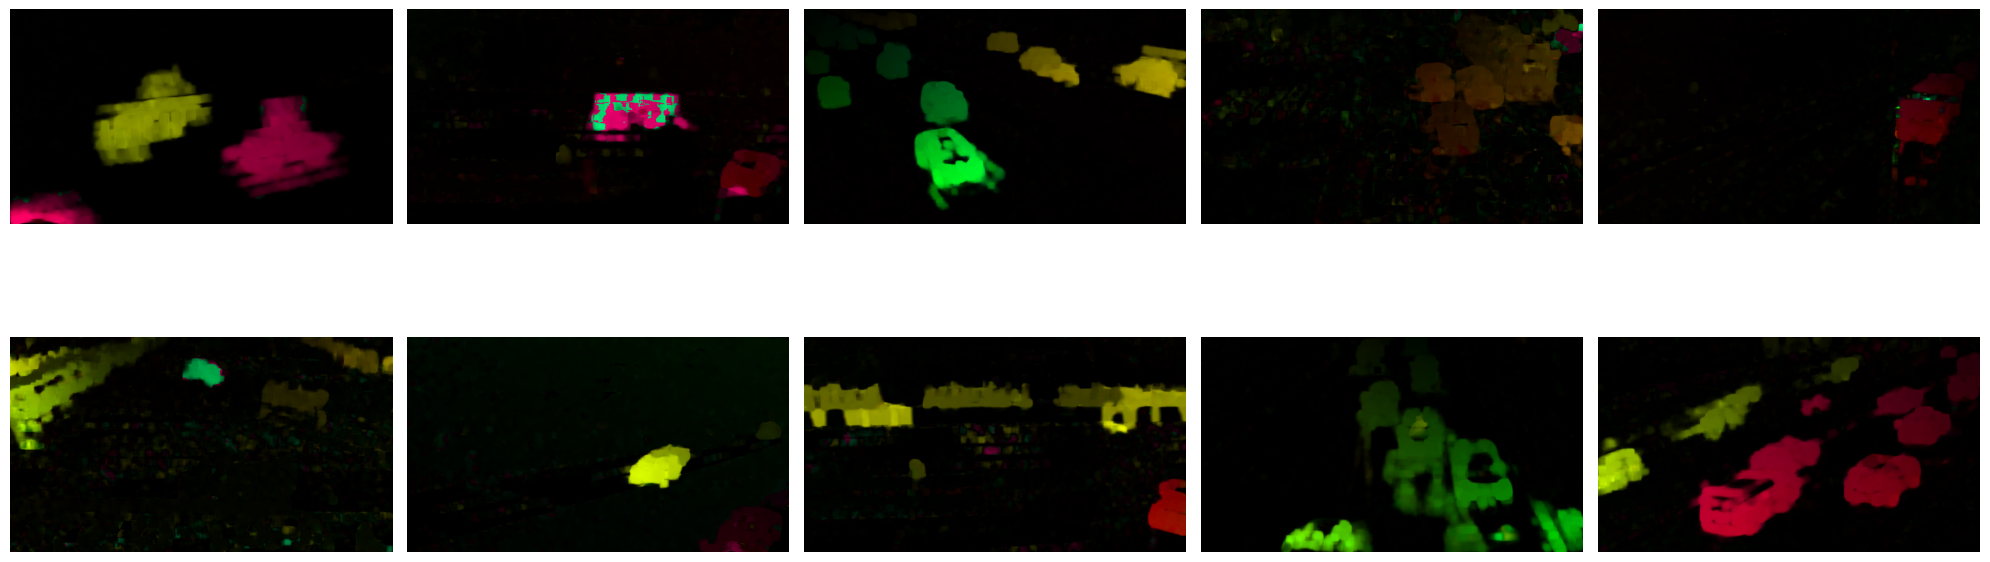

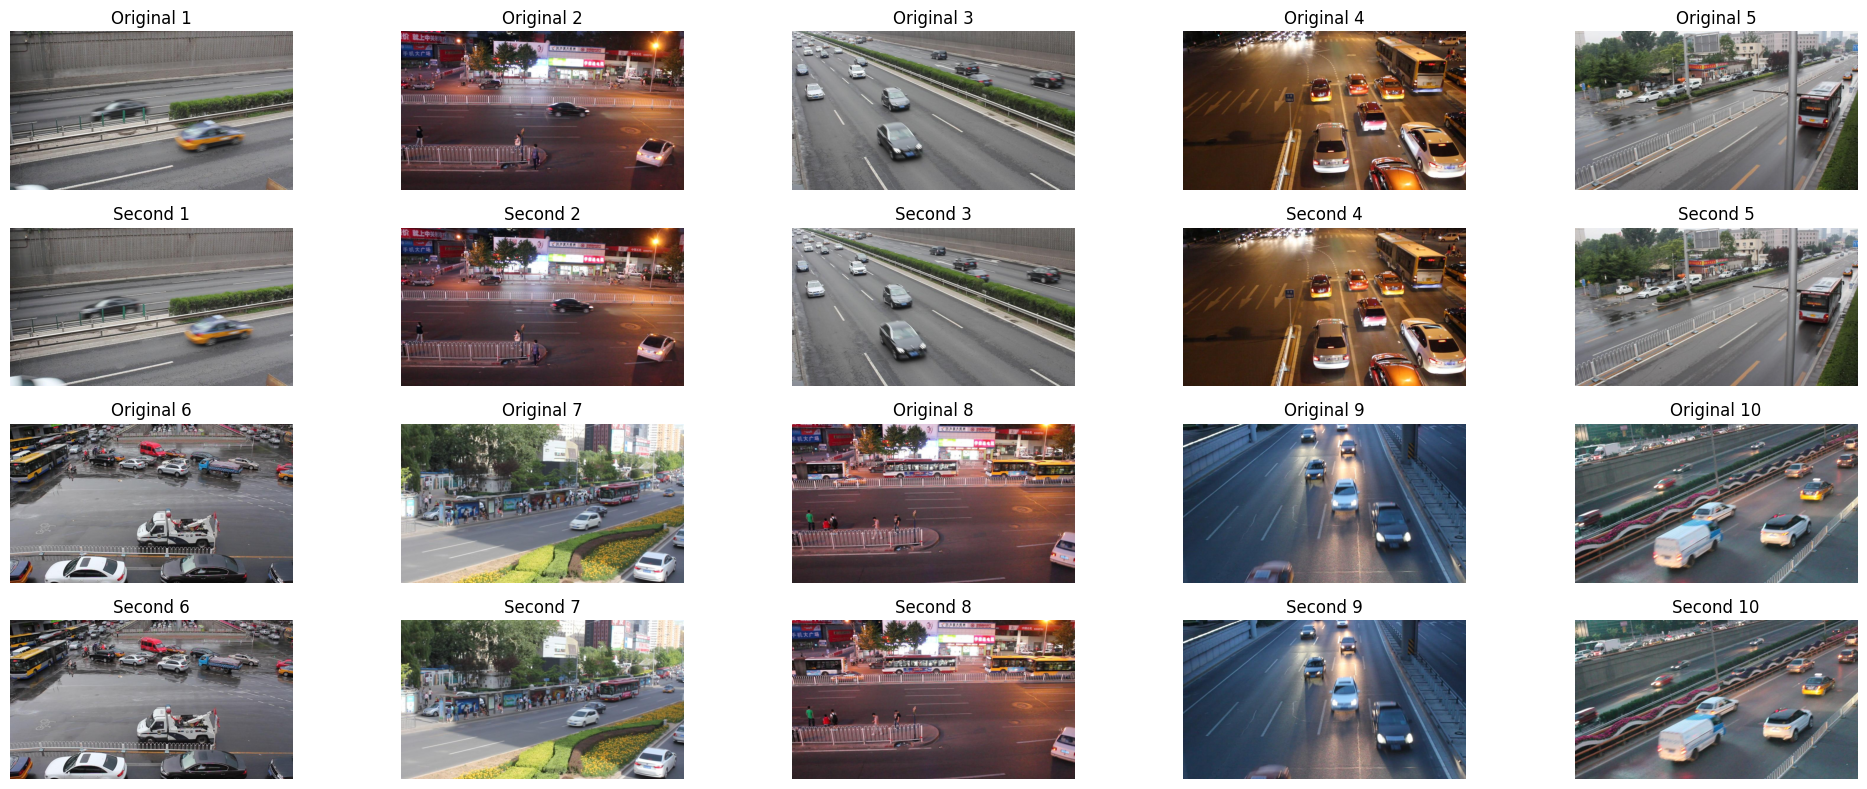

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for pair in pairs:
    flow = cv2.calcOpticalFlowFarneback(
        cv2.imread(str(pair[0]), cv2.IMREAD_GRAYSCALE),
        cv2.imread(str(pair[1]), cv2.IMREAD_GRAYSCALE),
        None, 0.5, 3, 15, 3, 5, 1.2, 0
    )

    hsv = np.zeros((flow.shape[0], flow.shape[1], 3), dtype=np.uint8)
    hsv[..., 1] = 255
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = (ang + np.pi) * 180 / (2* np.pi) / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    ax = axes.flatten()[pairs.index(pair)]
    ax.imshow(bgr)
    ax.axis('off')
    
plt.tight_layout()
plt.show()

original_images = [cv2.imread(str(pair[0])) for pair in pairs]
second_images = [cv2.imread(str(pair[1])) for pair in pairs]
fig, axes = plt.subplots(4, 5, figsize=(20, 8))
for i in range(5):
    axes[0, i].imshow(cv2.cvtColor(original_images[i], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f"Original {i+1}")
    axes[0, i].axis('off')

    axes[1, i].imshow(cv2.cvtColor(second_images[i], cv2.COLOR_BGR2RGB))
    axes[1, i].set_title(f"Second {i+1}")
    axes[1, i].axis('off')

    axes[2, i].imshow(cv2.cvtColor(original_images[i+5], cv2.COLOR_BGR2RGB))
    axes[2, i].set_title(f"Original {i+6}")
    axes[2, i].axis('off')

    axes[3, i].imshow(cv2.cvtColor(second_images[i+5], cv2.COLOR_BGR2RGB))
    axes[3, i].set_title(f"Second {i+6}")
    axes[3, i].axis('off')

plt.tight_layout()
plt.show()


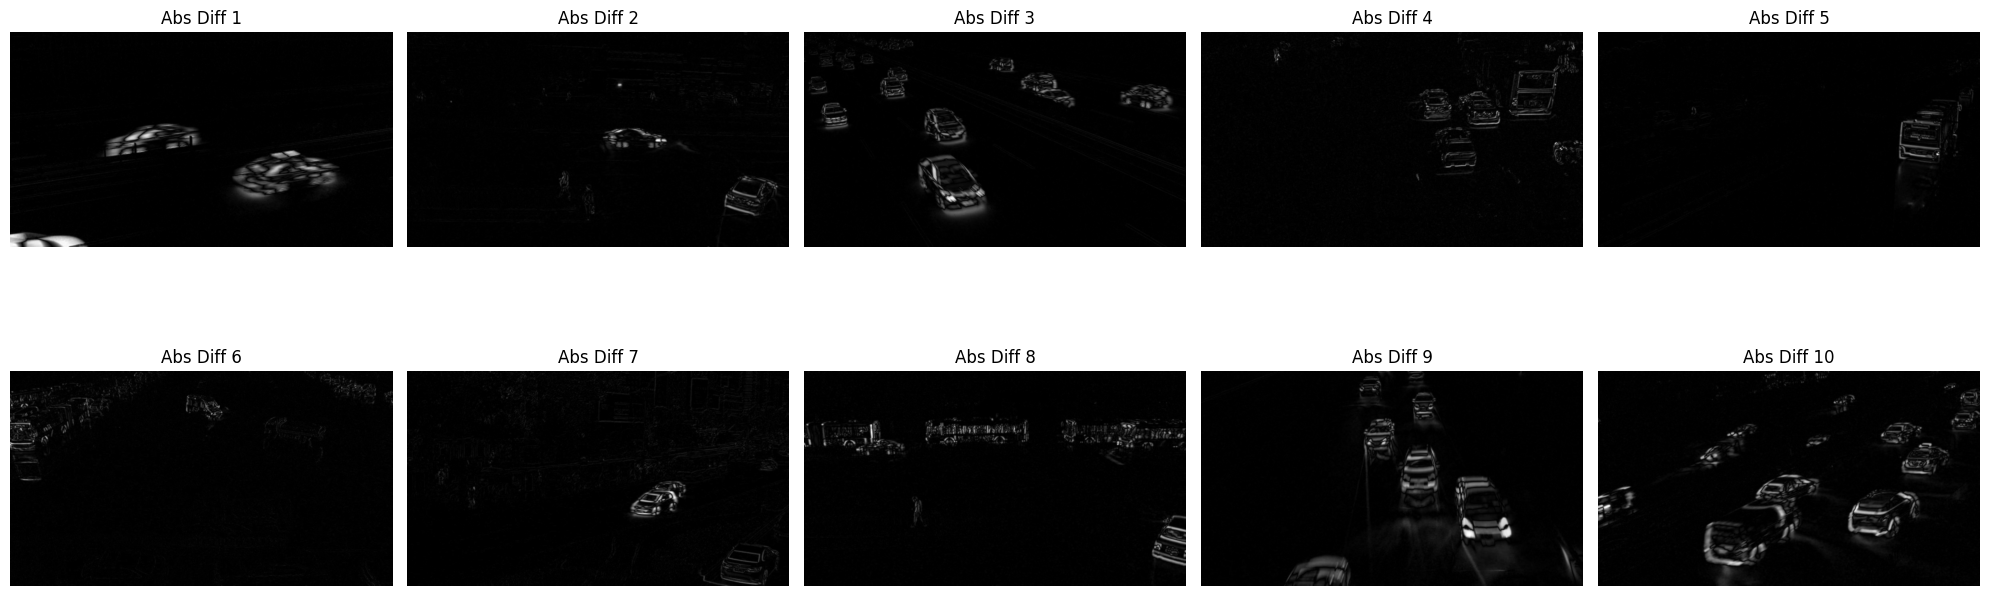

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for pair in pairs:
    image_a = cv2.imread(str(pair[0]), cv2.IMREAD_GRAYSCALE)
    image_b = cv2.imread(str(pair[1]), cv2.IMREAD_GRAYSCALE)
    blur_a = cv2.GaussianBlur(image_a, (5, 5), 1)
    blur_b = cv2.GaussianBlur(image_b, (5, 5), 1)
    abs_diff = cv2.absdiff(blur_a, blur_b)
    ax = axes.flatten()[pairs.index(pair)]
    ax.imshow(abs_diff, cmap='gray')
    ax.set_title(f"Abs Diff {pairs.index(pair)+1}")
    ax.axis('off')
plt.tight_layout()
plt.show()